# Pré-processamento
## Parte 2: Resample e Merge Temporal

### O problema central desta parte

O `full_table.parquet` tem um problema fundamental:
**os sinais foram gravados em frequências diferentes e concatenados
na mesma tabela sem harmonização.**

```
EEG/BIO:  1000 amostras/segundo  → 1 linha a cada 0.001s
IMU:       100 amostras/segundo  → 1 linha a cada 0.010s
```

Quando o `build_bronze_raw` juntou tudo numa tabela só usando `min_len`
(pegar o menor comprimento e cortar o resto), o resultado foi:
- O EEG ficou com 1000Hz de resolução
- O IMU ficou com 100Hz de resolução
- Mas ambos estão na mesma tabela, como se tivessem a mesma frequência

### O que esta parte faz

1. **Separa** os sinais por tipo (EEG/BIO e IMU)
2. **Resample do EEG/BIO:** 1000Hz → 500Hz por decimação (pega 1 amostra a cada 2)
3. **Resample do IMU:** 100Hz → 500Hz por interpolação spline cúbica
   (cria 4 amostras sintéticas entre cada par de amostras reais)
4. **Merge temporal:** junta EEG e IMU numa tabela única alinhada em 500Hz
5. **Neutraliza sensores mortos** detectados na Parte 1

---
### Entrada
- `data/bronze/full_table.parquet`

### Saída
- `data/silver/resampled.parquet` — todos os sinais a 500Hz, alinhados
---

## 0. Carregar definições da Parte 1

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.interpolate as spi
from scipy import signal as sg
from pathlib import Path

# ── Caminhos ──────────────────────────────────────────────────────────────────
ROOT           = Path("..")
RAW_PATH       = ROOT / "data" / "bronze" / "full_table.parquet"
SILVER_PATH    = ROOT / "data" / "silver"
RESAMPLED_PATH = SILVER_PATH / "resampled.parquet"
SILVER_PATH.mkdir(parents=True, exist_ok=True)

# ── Frequências ───────────────────────────────────────────────────────────────
EEG_FREQ_HZ    = 1000
IMU_FREQ_HZ    = 100
TARGET_FREQ_HZ = 500
TARGET_DT      = 1.0 / TARGET_FREQ_HZ   # 0.002s entre cada amostra no output
EEG_DOWN_FACTOR = EEG_FREQ_HZ // TARGET_FREQ_HZ   # = 2
IMU_UP_FACTOR   = TARGET_FREQ_HZ // IMU_FREQ_HZ   # = 5

# ── Nomes de colunas ──────────────────────────────────────────────────────────
EEG_COLS = [
    'EEG-FP1','EEG-FP2','EEG-F3','EEG-F4','EEG-C3','EEG-C4',
    'EEG-P3','EEG-P4','EEG-O1','EEG-O2','EEG-F7','EEG-F8',
    'EEG-P7','EEG-P8','EEG-FZ','EEG-CZ','EEG-PZ',
    'EEG-FC1','EEG-FC2','EEG-CP1','EEG-CP2',
    'EEG-FC5','EEG-FC6','EEG-CP5','EEG-CP6'
]
BIO_COLS       = ['EMG-RTA', 'EMG-LTA', 'EMG-RGS', 'IO', 'ECG']
SENSOR_NAMES   = ['LShank', 'RShank', 'Waist', 'Arm']
IMU_SUFFIXES_SINAL = ['ACCX', 'ACCY', 'ACCZ', 'GYRO-X', 'GYRO-Y', 'GYRO-Z']
IMU_SUFFIXES_ALL   = IMU_SUFFIXES_SINAL + ['NC/SC']
IMU_COLS_SINAL = [f"{s}-{ax}" for s in SENSOR_NAMES for ax in IMU_SUFFIXES_SINAL]
IMU_COLS_ALL   = [f"{s}-{ax}" for s in SENSOR_NAMES for ax in IMU_SUFFIXES_ALL]
META_COLS      = ['timestamp', 'patient_id', 'task_id', 'session']

# Limiar de sensor morto (da Parte 1)
ZERO_EPS       = 1e-8
MISSING_THRESH = 0.95

def sensor_morto(valores: np.ndarray) -> bool:
    return np.mean(np.abs(valores) < ZERO_EPS) > MISSING_THRESH

# ── Carregar RAW ──────────────────────────────────────────────────────────────
print("Carregando full_table.parquet...")
df_raw = pd.read_parquet(RAW_PATH)
print(f"Shape: {df_raw.shape[0]:,} × {df_raw.shape[1]}  "
      f"| Memória: {df_raw.memory_usage(deep=True).sum()/1e6:.1f} MB")
print("Definições carregadas.")

Carregando full_table.parquet...
Shape: 3,872,933 × 63  | Memória: 1105.8 MB
Definições carregadas.


## 1. Entender o problema de frequência no RAW

Antes de resamplear, vamos visualizar concretamente o problema:
EEG e IMU têm densidades de amostragem muito diferentes na mesma tabela.

In [4]:
# Mostra o intervalo médio entre amostras consecutivas por tipo de sinal
# Isso confirma numericamente o problema de frequências misturadas
print("INTERVALO ENTRE AMOSTRAS NO RAW (por paciente)")
print("Esperado EEG/BIO: ~0.001s (1ms) | IMU: ~0.010s (10ms)")
print("-" * 60)

pid_ex = sorted(df_raw['patient_id'].unique())[0]
df_ex  = df_raw[df_raw['patient_id'] == pid_ex].copy()
ts     = df_ex['timestamp'].astype(float).values
diffs  = np.diff(ts)

# Remove diffs negativos (regressões de timestamp entre sessões/tarefas)
diffs_positivos = diffs[diffs > 0]

print(f"\n  Paciente {pid_ex}:")
print(f"    Intervalo mínimo:  {diffs_positivos.min()*1000:.4f} ms")
print(f"    Intervalo mediano: {np.median(diffs_positivos)*1000:.4f} ms")
print(f"    Intervalo máximo:  {diffs_positivos.max()*1000:.4f} ms")
print(f"    Frequência aparente: ~{1/np.median(diffs_positivos):.0f} Hz")
print()
print("    → O timestamp no RAW reflete a frequência do EEG (1000Hz).")
print("      O IMU está na mesma tabela mas com resolução real de 100Hz:")
print("      cada 10 linhas de EEG correspondem a 1 ponto real de IMU.")

# Conta quantas linhas distintas o IMU tem vs o EEG para o mesmo paciente
col_imu_ex = next((c for c in IMU_COLS_SINAL if c in df_ex.columns
                   and df_ex[c].notna().any()), None)
if col_imu_ex:
    n_imu_unicos = df_ex[col_imu_ex].dropna().diff().ne(0).sum()
    n_eeg        = len(df_ex)
    print(f"\n    EEG: {n_eeg:,} amostras  |  "
          f"IMU ({col_imu_ex}): ~{n_imu_unicos:,} transições únicas")
    print(f"    Razão: {n_eeg/n_imu_unicos:.1f}x mais linhas que pontos IMU reais")

INTERVALO ENTRE AMOSTRAS NO RAW (por paciente)
Esperado EEG/BIO: ~0.001s (1ms) | IMU: ~0.010s (10ms)
------------------------------------------------------------

  Paciente 001:
    Intervalo mínimo:  1.0000 ms
    Intervalo mediano: 1.0000 ms
    Intervalo máximo:  197001.0000 ms
    Frequência aparente: ~1000 Hz

    → O timestamp no RAW reflete a frequência do EEG (1000Hz).
      O IMU está na mesma tabela mas com resolução real de 100Hz:
      cada 10 linhas de EEG correspondem a 1 ponto real de IMU.

    EEG: 221,164 amostras  |  IMU (LShank-ACCX): ~218,503 transições únicas
    Razão: 1.0x mais linhas que pontos IMU reais


## 2. Funções de Resample

Duas estratégias diferentes para dois problemas opostos:
- **EEG tem amostras demais** → decimação (jogar fora amostras)
- **IMU tem amostras de menos** → interpolação spline (criar amostras novas)

In [5]:
def resample_eeg(df_pid: pd.DataFrame) -> pd.DataFrame:
    """
    Reduz o EEG e BIO de 1000Hz para 500Hz por decimação.

    Decimação = pegar 1 amostra a cada N, descartando as demais.
    Com EEG_DOWN_FACTOR=2, pegamos as linhas de índice 0, 2, 4, 6...
    e descartamos 1, 3, 5, 7...

    Por que decimação e não média? Para EEG já filtrado seria aceitável
    usar média, mas nosso sinal ainda é bruto aqui — a Parte 3 vai filtrar.
    Decimação simples preserva os picos de sinal sem criar artefatos.

    Analogia: você tem um vídeo em 60fps e quer 30fps.
    A maneira mais simples é jogar fora um frame sim, um não.
    O resultado é igualmente fluido porque os frames são muito próximos.

    Entrada:  DataFrame de 1 paciente com N linhas a 1000Hz
    Saída:    DataFrame com N/2 linhas a 500Hz
    """
    # Pega 1 linha a cada EEG_DOWN_FACTOR (= a cada 2)
    df_down = df_pid.iloc[::EEG_DOWN_FACTOR].copy()
    df_down = df_down.reset_index(drop=True)
    return df_down


def resample_imu_spline(valores: np.ndarray, fator: int = IMU_UP_FACTOR) -> np.ndarray:
    """
    Aumenta a resolução de um canal IMU de 100Hz para 500Hz
    usando interpolação spline cúbica (grau 3).

    Spline cúbico = ajusta uma curva suave que passa por todos os pontos
    reais e estima os pontos intermediários de forma natural, sem cantos.

    Analogia: você tem fotos de um corredor a cada 10 metros
    e quer fotos a cada 2 metros. O spline 'imagina' como seria
    o corredor nos intervalos, baseado na curvatura dos pontos conhecidos.
    Uma régua (linear) funcionaria, mas o spline respeita a suavidade
    do movimento humano — que raramente muda de direção abruptamente.

    Parâmetros:
        valores : array com N pontos reais a 100Hz
        fator   : quantas amostras gerar por ponto original (padrão = 5)

    Retorna:
        array com N*fator pontos a 500Hz
    """
    n = len(valores)
    if n < 4:
        # Spline cúbico precisa de pelo menos 4 pontos para funcionar
        # Se o trecho for muito curto, usa interpolação linear
        x_orig = np.arange(n)
        x_novo = np.linspace(0, n - 1, n * fator)
        return np.interp(x_novo, x_orig, valores).astype('float32')

    # Índices originais: [0, 1, 2, 3, ..., N-1]
    x_orig = np.arange(n)

    # Índices novos: [0, 0.2, 0.4, ..., N-1] — 5x mais densos
    # Exemplo: N=10 pontos → 50 pontos novos de 0.0 até 9.0 em passos de 0.2
    x_novo = np.linspace(0, n - 1, n * fator)

    # Ajusta a curva spline de grau 3 pelos pontos originais
    tck = spi.splrep(x_orig, valores, k=3, s=0)

    # Calcula os valores interpolados nos novos pontos
    valores_interpolados = spi.splev(x_novo, tck)

    return valores_interpolados.astype('float32')


print("Funções de resample definidas.")

Funções de resample definidas.


## 3. Visualizar o Efeito do Resample (antes de aplicar em tudo)

Antes de processar todos os pacientes, vale conferir visualmente
se o resample está funcionando como esperado num trecho pequeno.

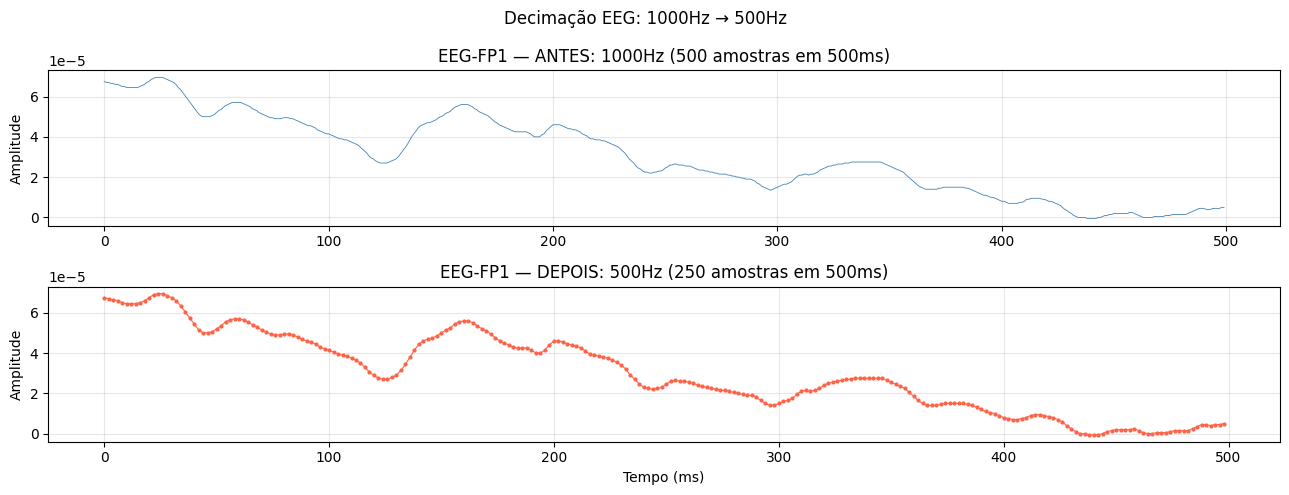

O sinal deve parecer idêntico — só metade das amostras.


In [6]:
# ── Demonstração do downsample do EEG ─────────────────────────────────────────
pid_ex    = sorted(df_raw['patient_id'].unique())[0]
col_eeg   = next((c for c in EEG_COLS if c in df_raw.columns
                  and df_raw[df_raw['patient_id']==pid_ex][c].notna().any()), None)

if col_eeg:
    trecho_1000 = df_raw[df_raw['patient_id']==pid_ex][col_eeg].dropna().values[:500]
    trecho_500  = trecho_1000[::EEG_DOWN_FACTOR]   # decimação simples

    t_1000 = np.arange(len(trecho_1000)) / EEG_FREQ_HZ * 1000   # em ms
    t_500  = np.arange(len(trecho_500))  / TARGET_FREQ_HZ * 1000

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5), sharex=False)
    ax1.plot(t_1000, trecho_1000, lw=0.6, color='steelblue')
    ax1.set_title(f"{col_eeg} — ANTES: 1000Hz ({len(trecho_1000)} amostras em 500ms)")
    ax1.set_ylabel("Amplitude"); ax1.grid(alpha=0.3)

    ax2.plot(t_500,  trecho_500,  lw=0.8, color='tomato',
             marker='o', markersize=2)
    ax2.set_title(f"{col_eeg} — DEPOIS: 500Hz ({len(trecho_500)} amostras em 500ms)")
    ax2.set_ylabel("Amplitude"); ax2.set_xlabel("Tempo (ms)"); ax2.grid(alpha=0.3)

    plt.suptitle("Decimação EEG: 1000Hz → 500Hz", fontsize=12)
    plt.tight_layout()
    plt.show()
    print("O sinal deve parecer idêntico — só metade das amostras.")

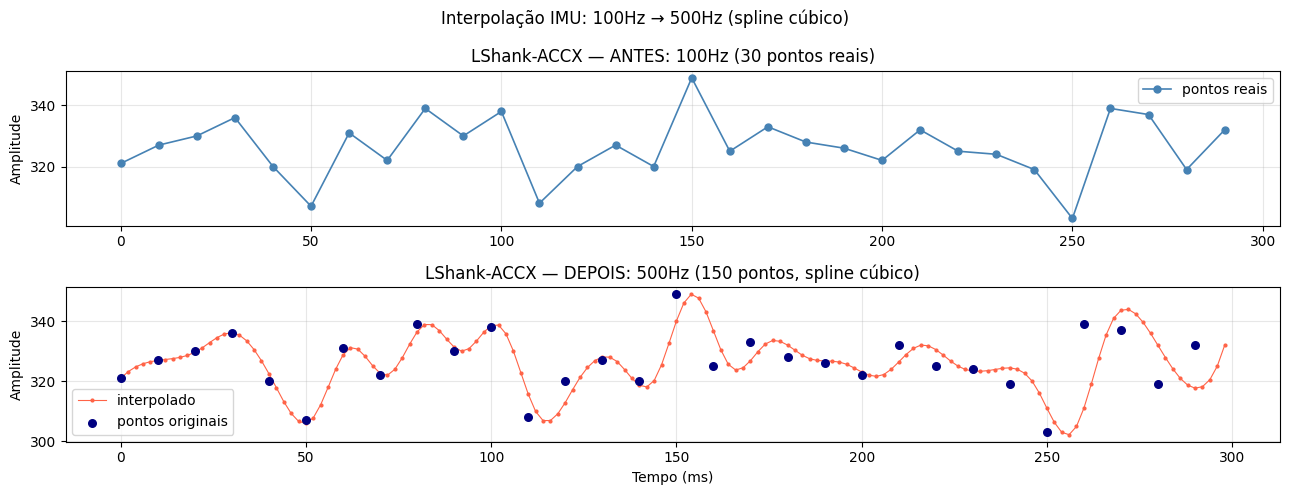

Os pontos azuis (originais) devem estar exatamente na curva vermelha.


In [7]:
# ── Demonstração do upsample do IMU por spline ────────────────────────────────
col_imu = next((c for c in IMU_COLS_SINAL if c in df_raw.columns
                and df_raw[df_raw['patient_id']==pid_ex][c].notna().any()), None)

if col_imu:
    # Pega pontos IMU reais: como o IMU está a 100Hz mas na tabela de 1000Hz,
    # cada ponto real aparece repetido 10 vezes. Removemos as repetições.
    imu_raw_series = df_raw[df_raw['patient_id']==pid_ex][col_imu].dropna()
    # Extrai só os pontos onde o valor muda (pontos reais de 100Hz)
    imu_100hz = imu_raw_series[imu_raw_series.diff().ne(0)].values[:30]

    imu_500hz = resample_imu_spline(imu_100hz)

    t_100 = np.arange(len(imu_100hz)) * (1.0/IMU_FREQ_HZ) * 1000    # em ms
    t_500 = np.arange(len(imu_500hz)) * TARGET_DT * 1000

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5))
    ax1.plot(t_100, imu_100hz, lw=1.2, color='steelblue',
             marker='o', markersize=5, label='pontos reais')
    ax1.set_title(f"{col_imu} — ANTES: 100Hz ({len(imu_100hz)} pontos reais)")
    ax1.set_ylabel("Amplitude"); ax1.legend(); ax1.grid(alpha=0.3)

    ax2.plot(t_500, imu_500hz, lw=0.8, color='tomato',
             marker='o', markersize=2, label='interpolado')
    # Marca os pontos originais no gráfico interpolado
    t_orig_no_novo = np.arange(len(imu_100hz)) * IMU_UP_FACTOR * TARGET_DT * 1000
    ax2.scatter(t_orig_no_novo, imu_100hz, color='navy',
                s=30, zorder=5, label='pontos originais')
    ax2.set_title(f"{col_imu} — DEPOIS: 500Hz ({len(imu_500hz)} pontos, spline cúbico)")
    ax2.set_ylabel("Amplitude"); ax2.set_xlabel("Tempo (ms)")
    ax2.legend(); ax2.grid(alpha=0.3)

    plt.suptitle("Interpolação IMU: 100Hz → 500Hz (spline cúbico)", fontsize=12)
    plt.tight_layout()
    plt.show()
    print("Os pontos azuis (originais) devem estar exatamente na curva vermelha.")

## 4. Pipeline de Resample por Paciente × Sessão

Processamos **um bloco por vez** (paciente + sessão).

> **Por que não o dataset inteiro de uma vez?**
> O timestamp reinicia em cada sessão de cada paciente.
> Misturar sessões diferentes no mesmo resample criaria
> artefatos enormes nas fronteiras — o algoritmo tentaria
> interpolar entre o último ponto de um paciente e o
> primeiro do próximo, que são completamente não relacionados.

In [8]:
def extrair_imu_100hz(df_pid: pd.DataFrame) -> pd.DataFrame:
    """
    Extrai os pontos reais de IMU (100Hz) de um bloco paciente+sessão.

    No RAW, o IMU está repetido 10 vezes em cada linha do EEG.
    Exemplo: se o EEG tem 10.000 linhas, o IMU tem 10.000 linhas
    mas apenas ~1.000 valores únicos — os outros 9.000 são cópias.

    Esta função detecta os pontos de transição (onde o IMU muda de valor)
    e retorna apenas esses pontos reais, junto com o timestamp correspondente.

    Analogia: numa câmera a 10fps em slow-motion 100fps, cada frame real
    aparece repetido 10 vezes. Esta função pega só o frame original.
    """
    # Usamos LShank-ACCX como canal de referência para detectar transições
    # Se LShank não existe, usamos o primeiro IMU disponível
    col_ref = next(
        (c for c in IMU_COLS_SINAL if c in df_pid.columns and df_pid[c].notna().any()),
        None
    )

    if col_ref is None:
        # Nenhum IMU disponível para este paciente — retorna DataFrame vazio
        return pd.DataFrame()

    # Marca as linhas onde o sinal IMU de referência muda de valor
    # A primeira linha sempre é True (ponto de início)
    mascara_transicao = df_pid[col_ref].diff().ne(0) | (df_pid.index == df_pid.index[0])

    # Extrai todas as colunas IMU apenas nas linhas de transição
    cols_imu_presentes = [c for c in IMU_COLS_ALL if c in df_pid.columns]
    df_imu_real = df_pid.loc[mascara_transicao, ['timestamp'] + cols_imu_presentes].copy()
    df_imu_real = df_imu_real.reset_index(drop=True)

    return df_imu_real


def resample_bloco(df_bloco: pd.DataFrame, pid: str, sessao: str) -> pd.DataFrame:
    """
    Faz o resample completo de um bloco paciente+sessão.

    Passos:
    1. Decima EEG/BIO de 1000Hz para 500Hz
    2. Extrai pontos reais de IMU (100Hz)
    3. Interpola IMU de 100Hz para 500Hz com spline cúbico
    4. Cria um timestamp unificado a 500Hz para o bloco inteiro
    5. Merge EEG decimado + IMU interpolado pelo timestamp
    6. Neutraliza sensores mortos (substitui zeros por NaN)

    Retorna DataFrame com todos os sinais alinhados a 500Hz.
    """
    # ── Passo 1: Decimar EEG/BIO ──────────────────────────────────────────────
    # Colunas EEG e BIO que existem neste bloco
    cols_eeg_bio = [c for c in (EEG_COLS + BIO_COLS) if c in df_bloco.columns]

    # Decima: pega 1 linha a cada 2 (índices 0, 2, 4, 6...)
    df_eeg_500 = df_bloco.iloc[::EEG_DOWN_FACTOR][['timestamp'] + cols_eeg_bio].copy()
    df_eeg_500 = df_eeg_500.reset_index(drop=True)

    # Recalcula o timestamp: a 500Hz, cada amostra está a TARGET_DT segundos
    # Usamos o timestamp original do primeiro ponto como âncora
    ts_inicio = float(df_bloco['timestamp'].iloc[0])
    n_eeg     = len(df_eeg_500)
    ts_500hz  = ts_inicio + np.arange(n_eeg) * TARGET_DT
    df_eeg_500['timestamp'] = ts_500hz

    # ── Passo 2: Extrair pontos reais de IMU a 100Hz ──────────────────────────
    df_imu_100 = extrair_imu_100hz(df_bloco)

    if df_imu_100.empty:
        # Sem IMU: adiciona colunas com NaN e retorna só o EEG
        for col in IMU_COLS_ALL:
            df_eeg_500[col] = np.nan
        df_eeg_500['patient_id'] = pid
        df_eeg_500['session']    = sessao
        df_eeg_500['task_id']    = df_bloco['task_id'].iloc[0] \
                                   if 'task_id' in df_bloco.columns else 'unknown'
        df_eeg_500['label']      = np.nan
        return df_eeg_500

    # ── Passo 3: Interpolar IMU de 100Hz para 500Hz ───────────────────────────
    # Número de pontos no output: mesmo que o EEG decimado
    # (ambos representam o mesmo intervalo de tempo)
    n_target = len(df_eeg_500)

    df_imu_500 = pd.DataFrame({'timestamp': ts_500hz})

    cols_imu_presentes = [c for c in IMU_COLS_ALL if c in df_imu_100.columns]

    for col in cols_imu_presentes:
        valores_100hz = df_imu_100[col].values.astype(float)

        # Se o canal for 100% NaN, mantém NaN
        if np.all(np.isnan(valores_100hz)):
            df_imu_500[col] = np.nan
            continue

        # NC/SC não é sinal contínuo — não faz sentido interpolar
        # Replica o valor mais próximo (nearest-neighbor)
        if col.endswith('NC/SC'):
            x_100 = np.linspace(0, 1, len(valores_100hz))
            x_500 = np.linspace(0, 1, n_target)
            interpolado = np.interp(x_500, x_100, valores_100hz)
            df_imu_500[col] = interpolado.astype('float32')
            continue

        # Para ACC e GYRO: spline cúbico
        n_100 = len(valores_100hz)
        x_100 = np.linspace(0, 1, n_100)
        x_500 = np.linspace(0, 1, n_target)

        if n_100 >= 4:
            tck  = spi.splrep(x_100, valores_100hz, k=3, s=0)
            vals = spi.splev(x_500, tck)
        else:
            # Trecho curto: interpolação linear como fallback
            vals = np.interp(x_500, x_100, valores_100hz)

        df_imu_500[col] = vals.astype('float32')

    # ── Passo 4: Neutralizar sensores mortos no IMU interpolado ───────────────
    # Sensor morto = gravou zeros → após interpolação continua zero
    # Substituímos por NaN para não enganar etapas posteriores
    for col in [c for c in IMU_COLS_SINAL if c in df_imu_500.columns]:
        vals = df_imu_500[col].dropna().values
        if len(vals) > 0 and sensor_morto(vals):
            df_imu_500[col] = np.nan

    # ── Passo 5: Merge EEG + IMU pelo timestamp ───────────────────────────────
    # merge_asof faz um join aproximado: para cada timestamp do EEG (500Hz),
    # encontra o ponto IMU mais próximo no tempo
    # Isso é mais robusto que um merge exato, que falharia por diferenças
    # de arredondamento de float no timestamp
    df_eeg_500  = df_eeg_500.sort_values('timestamp')
    df_imu_500  = df_imu_500.sort_values('timestamp')

    df_merged = pd.merge_asof(
        df_eeg_500,
        df_imu_500,
        on='timestamp',
        direction='nearest',
        tolerance=TARGET_DT * 1.5   # aceita até 1.5× o intervalo de distância
    )

    # ── Passo 6: Reatachar metadados ──────────────────────────────────────────
    df_merged['patient_id'] = pid
    df_merged['session']    = sessao
    df_merged['task_id']    = df_bloco['task_id'].iloc[0] \
                              if 'task_id' in df_bloco.columns else 'unknown'
    df_merged['label']      = np.nan   # label permanece vazio até a Parte 4

    return df_merged


print("Funções de pipeline definidas.")

Funções de pipeline definidas.


In [9]:
# ── Executa o resample em todos os pacientes e sessões ────────────────────────
print("Iniciando resample...")
print("-" * 55)

blocos_resampled = []

grupos = df_raw.groupby(['patient_id', 'session'], sort=True)

for (pid, sessao), df_bloco in grupos:
    n_entrada = len(df_bloco)

    df_res = resample_bloco(df_bloco.copy(), pid, sessao)

    n_saida    = len(df_res)
    reducao    = (1 - n_saida / n_entrada) * 100

    blocos_resampled.append(df_res)
    print(f"  {pid} / sessão {sessao}: "
          f"{n_entrada:>8,} → {n_saida:>8,} amostras  "
          f"(redução de {reducao:.1f}%)")

# Concatena todos os blocos
df_resampled = pd.concat(blocos_resampled, ignore_index=True)

print(f"\nShape final: {df_resampled.shape[0]:,} × {df_resampled.shape[1]}")
print(f"Memória:     {df_resampled.memory_usage(deep=True).sum()/1e6:.1f} MB")

Iniciando resample...
-------------------------------------------------------
  001 / sessão 1:  221,164 →  110,582 amostras  (redução de 50.0%)
  002 / sessão 1:  470,195 →  235,098 amostras  (redução de 50.0%)
  003 / sessão 1:  522,769 →  261,385 amostras  (redução de 50.0%)
  004 / sessão 1:  224,654 →  112,327 amostras  (redução de 50.0%)
  005 / sessão 1:  184,702 →   92,351 amostras  (redução de 50.0%)
  006 / sessão 1:  216,129 →  108,065 amostras  (redução de 50.0%)
  007 / sessão 1:  326,607 →  163,304 amostras  (redução de 50.0%)
  008 / sessão 1:  197,819 →   98,910 amostras  (redução de 50.0%)
  008 / sessão 2:  170,220 →   85,110 amostras  (redução de 50.0%)
  009 / sessão 1:  271,612 →  135,806 amostras  (redução de 50.0%)
  010 / sessão 1:  431,039 →  215,520 amostras  (redução de 50.0%)
  011 / sessão 1:  332,615 →  166,308 amostras  (redução de 50.0%)
  012 / sessão 1:  303,408 →  151,704 amostras  (redução de 50.0%)

Shape final: 1,936,470 × 63
Memória:     765.6 MB


## 5. Verificação Pós-Resample

In [10]:
# ── 5.1 Confirma que a frequência agora é 500Hz ───────────────────────────────
print("VERIFICAÇÃO DE FREQUÊNCIA PÓS-RESAMPLE")
print(f"Esperado: {TARGET_FREQ_HZ}Hz  (intervalo de {TARGET_DT*1000:.1f}ms)")
print("-" * 55)

for (pid, sessao), df_bloco in df_resampled.groupby(['patient_id', 'session']):
    ts    = df_bloco['timestamp'].astype(float).values
    diffs = np.diff(ts)
    diffs_pos = diffs[diffs > 0]
    if len(diffs_pos) == 0:
        print(f"  {pid}/s{sessao}: sem diffs positivos")
        continue
    dt_med  = np.median(diffs_pos)
    freq_hz = 1.0 / dt_med
    ok      = abs(freq_hz - TARGET_FREQ_HZ) < 5   # tolerância de ±5Hz
    status  = "✅" if ok else f"{freq_hz:.1f}Hz"
    print(f"  {pid} / sessão {sessao}: {freq_hz:>6.1f}Hz  "
          f"dt={dt_med*1000:.3f}ms  {status}")

VERIFICAÇÃO DE FREQUÊNCIA PÓS-RESAMPLE
Esperado: 500Hz  (intervalo de 2.0ms)
-------------------------------------------------------
  001 / sessão 1:  500.0Hz  dt=2.000ms  ✅
  002 / sessão 1:  500.0Hz  dt=2.000ms  ✅
  003 / sessão 1:  500.0Hz  dt=2.000ms  ✅
  004 / sessão 1:  500.0Hz  dt=2.000ms  ✅
  005 / sessão 1:  500.0Hz  dt=2.000ms  ✅
  006 / sessão 1:  500.0Hz  dt=2.000ms  ✅
  007 / sessão 1:  500.0Hz  dt=2.000ms  ✅
  008 / sessão 1:  500.0Hz  dt=2.000ms  ✅
  008 / sessão 2:  500.0Hz  dt=2.000ms  ✅
  009 / sessão 1:  500.0Hz  dt=2.000ms  ✅
  010 / sessão 1:  500.0Hz  dt=2.000ms  ✅
  011 / sessão 1:  500.0Hz  dt=2.000ms  ✅
  012 / sessão 1:  500.0Hz  dt=2.000ms  ✅


In [11]:
# ── 5.2 NaNs por tipo de sinal ────────────────────────────────────────────────
print("NaNs PÓS-RESAMPLE (por tipo de sinal)")
print("-" * 55)

for grupo, cols in [("EEG", EEG_COLS), ("BIO", BIO_COLS), ("IMU", IMU_COLS_ALL)]:
    cols_pres = [c for c in cols if c in df_resampled.columns]
    if not cols_pres:
        continue

    # remove canais totalmente ausentes (100% NaN)
    cols_validas = [
        c for c in cols_pres
        if not df_resampled[c].isna().all()
    ]

    if not cols_validas:
        continue

    pct_nan = df_resampled[cols_validas].isna().mean().mean() * 100

    if grupo == "IMU":
        aviso = ""
    else:
        aviso = " inesperado" if pct_nan > 0 else ""

    print(f"  {grupo:<5}: {pct_nan:6.1f}% NaN médio{aviso}")
print("\nInterpretação:")
print(
    "Os percentuais médios de NaN em EEG e BIO observados após o resample "
    "\nnão representam falhas inesperadas no pré-processamento. Esses valores "
    "\nsão consequência da existência de canais estruturalmente ausentes no "
    "\ndataset, como EEG-FZ, EEG-CZ, EEG-PZ e IO, que possuem 100% de NaN "
    "\ndesde a coleta original. Após remover esses canais totalmente ausentes "
    "\ndo cálculo, espera-se que EEG e BIO apresentem aproximadamente 0% de NaN, "
    "\nindicando que os sinais efetivamente coletados foram preservados durante "
    "\no resample. Já os sinais de IMU continuam apresentando NaNs porque há "
    "\nsensores ausentes em alguns pacientes e também buracos reais nos sinais."
)

NaNs PÓS-RESAMPLE (por tipo de sinal)
-------------------------------------------------------
  EEG  :    0.0% NaN médio
  BIO  :    0.0% NaN médio
  IMU  :   32.0% NaN médio

Interpretação:
Os percentuais médios de NaN em EEG e BIO observados após o resample 
não representam falhas inesperadas no pré-processamento. Esses valores 
são consequência da existência de canais estruturalmente ausentes no 
dataset, como EEG-FZ, EEG-CZ, EEG-PZ e IO, que possuem 100% de NaN 
desde a coleta original. Após remover esses canais totalmente ausentes 
do cálculo, espera-se que EEG e BIO apresentem aproximadamente 0% de NaN, 
indicando que os sinais efetivamente coletados foram preservados durante 
o resample. Já os sinais de IMU continuam apresentando NaNs porque há 
sensores ausentes em alguns pacientes e também buracos reais nos sinais.


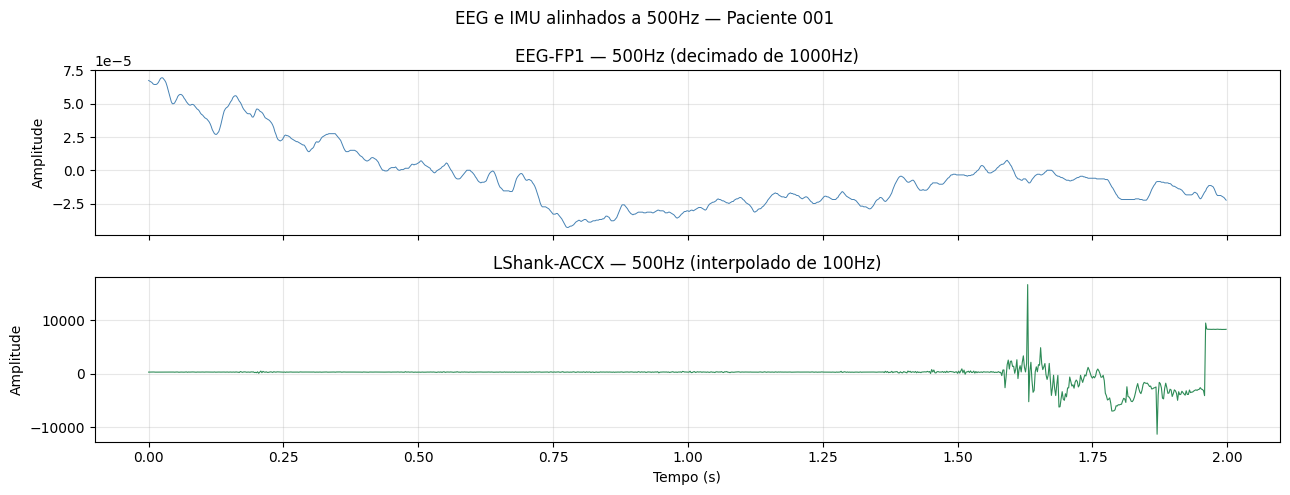

Os dois sinais agora têm o mesmo número de amostras por segundo.


In [12]:
# ── 5.3 Visualização: EEG e IMU alinhados no tempo ───────────────────────────
# Plota EEG e IMU no mesmo eixo de tempo para confirmar alinhamento
pid_ex   = sorted(df_resampled['patient_id'].unique())[0]
df_ex    = df_resampled[df_resampled['patient_id'] == pid_ex]
N_PLOT   = 1000   # 2 segundos a 500Hz

col_eeg  = next((c for c in EEG_COLS if c in df_ex.columns
                 and df_ex[c].notna().any()), None)
col_imu  = next((c for c in IMU_COLS_SINAL if c in df_ex.columns
                 and df_ex[c].notna().any()), None)

if col_eeg and col_imu:
    tempo = df_ex['timestamp'].astype(float).values[:N_PLOT]
    tempo = tempo - tempo[0]   # começa do zero para facilitar leitura

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 5), sharex=True)

    ax1.plot(tempo, df_ex[col_eeg].values[:N_PLOT], lw=0.7, color='steelblue')
    ax1.set_title(f"{col_eeg} — 500Hz (decimado de 1000Hz)")
    ax1.set_ylabel("Amplitude"); ax1.grid(alpha=0.3)

    ax2.plot(tempo, df_ex[col_imu].values[:N_PLOT], lw=0.8, color='seagreen')
    ax2.set_title(f"{col_imu} — 500Hz (interpolado de 100Hz)")
    ax2.set_ylabel("Amplitude"); ax2.set_xlabel("Tempo (s)")
    ax2.grid(alpha=0.3)

    plt.suptitle(f"EEG e IMU alinhados a 500Hz — Paciente {pid_ex}", fontsize=12)
    plt.tight_layout()
    plt.show()
    print("Os dois sinais agora têm o mesmo número de amostras por segundo.")

## 6. Salvar

In [13]:
# Ordena pela coluna patient_id + timestamp antes de salvar
df_resampled = df_resampled.sort_values(['patient_id', 'session', 'timestamp'])
df_resampled = df_resampled.reset_index(drop=True)

# Converte colunas de sinal para float32 (economiza ~50% de memória vs float64)
for col in [c for c in (EEG_COLS + BIO_COLS + IMU_COLS_ALL) if c in df_resampled.columns]:
    df_resampled[col] = df_resampled[col].astype('float32')

df_resampled.to_parquet(RESAMPLED_PATH, index=False)

print(f"Salvo: {RESAMPLED_PATH}")
print(f"  Linhas:   {len(df_resampled):,}")
print(f"  Colunas:  {df_resampled.shape[1]}")
print(f"  Memória:  {df_resampled.memory_usage(deep=True).sum()/1e6:.1f} MB")
print("\n Parte 2 concluída.")
print("   Todos os sinais estão a 500Hz e alinhados no tempo.")
print("   Prossiga para a Parte 3: Filtragem dos Sinais.")

Salvo: ../data/silver/resampled.parquet
  Linhas:   1,936,470
  Colunas:  63
  Memória:  548.7 MB

 Parte 2 concluída.
   Todos os sinais estão a 500Hz e alinhados no tempo.
   Prossiga para a Parte 3: Filtragem dos Sinais.
